# Prozesssimulation (Bachelor)
## Übung 4: Grundlagen der Reaktormodellierung
### Simulation von Rührkesselreaktoren

In dieser Übung werden wir die in Kapitel 4 des Skripts hergeleiteten Reaktormodelle Schritt für Schritt in Python implementieren. Wir verwenden `scipy.integrate.solve_ivp` zur Lösung der Differentialgleichungen und `matplotlib` zur Visualisierung der Ergebnisse.

**Bezeichnungen im Code** (wie im Skript): Konzentrationen $C_A$, $C_B$ → `C_A`, `C_B`; Geschwindigkeitskonstante $k$ → `k`; präexponentieller Faktor $k_0$ → `k_0`; Aktivierungsenergie $E_a$ → `E_a`; Reaktionsenthalpie $\Delta H_R$ → `dH_R`; Wärmeübertragungsfläche $A_W$ → `A_W`; Kühlmitteltemperatur $T_K$ → `T_K`.

### 1. Bibliotheken importieren

Zuerst importieren wir alle notwendigen Bibliotheken.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Globale Einstellungen für die Plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 14

### Schritt 1: Isothermer Batch-Reaktor (Skript, Abschnitt 4.1)

Wir beginnen mit dem einfachsten Fall: einer irreversiblen Reaktion 1. Ordnung ($A \rightarrow B$) in einem isothermen Batch-Reaktor. Die Temperatur ist konstant, daher ist auch die Geschwindigkeitskonstante $k$ konstant.

**Modell:**
Wir lösen eine einzige ODE:
$$
\frac{dC_A}{dt} = -k \cdot C_A
$$

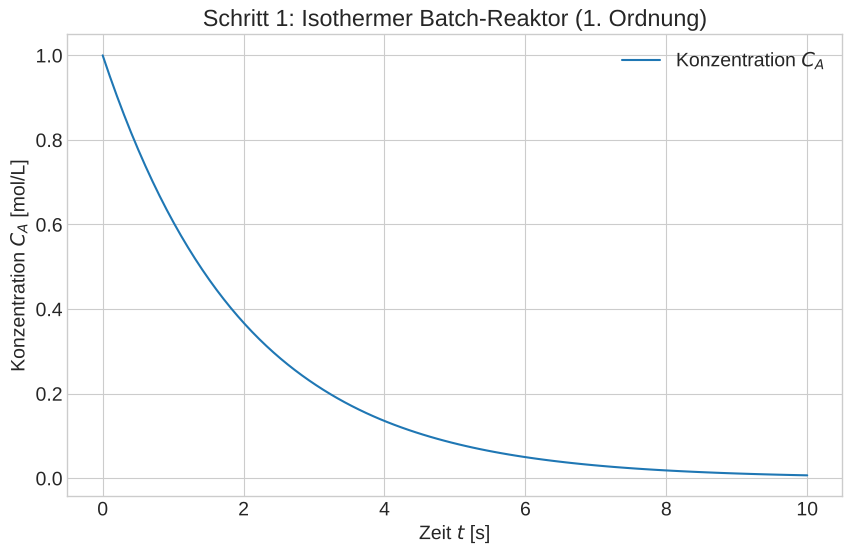

In [2]:
# --- Parameter für Schritt 1 ---
k = 0.5     # Geschwindigkeitskonstante [1/s]
C_A0 = 1.0  # Anfangskonzentration von A [mol/L]

# --- Zeitintervall ---
t_span = [0, 10]  # 10 Sekunden Simulation
t_eval = np.linspace(t_span[0], t_span[1], 100)

# --- ODE-Funktion ---
def model_step1(t, y):
    C_A = ##########

    # Differentialgleichung
    dCA_dt = ##########

    return [##########]

# --- Simulation ---
# y0 ist der Vektor der Anfangsbedingungen
y0_step1 = [C_A0]
sol_step1 = solve_ivp(model_step1, t_span, y0_step1, t_eval=t_eval)

# --- Plotten ---
plt.figure()
plt.plot(sol_step1.t, sol_step1.y[0], label='Konzentration $C_A$')
plt.xlabel('Zeit $t$ [s]')
plt.ylabel('Konzentration $C_A$ [mol/L]')
plt.title('Schritt 1: Isothermer Batch-Reaktor (1. Ordnung)')
plt.legend()
plt.grid(True)
plt.show()

#### Schritt 2: Nicht-isothermer Batch-Reaktor (Skript, Abschnitte 4.2 & 4.3)

Jetzt lassen wir die Temperatur $T$ variabel sein. Wir haben eine exotherme Reaktion, die Wärme erzeugt, und einen Kühlmantel, der Wärme abführt. Das System besteht aus zwei gekoppelten ODEs.

**Modell:**
$$
\frac{dC_A}{dt} = -k(T) \cdot C_A
$$
$$
\frac{dT}{dt} = \frac{(-\Delta H_R)}{\rho \cdot c_p} \cdot k(T) \cdot C_A - \frac{U \cdot A_W}{\rho \cdot V \cdot c_p} \cdot (T - T_K)
$$
Mit der Arrhenius-Gleichung:
$$
k(T) = k_0 \cdot \exp\left(-\frac{E_a}{R \cdot T}\right)
$$

**Hinweis zu den Einheiten:** Für die Simulation nehmen wir an, dass alle Parameter in SI-Basiseinheiten vorliegen. Die Konzentration $C_A$ wird daher in $\mathrm{mol/m^3}$ berechnet (wobei $1\ \mathrm{mol/L} = 1000\ \mathrm{mol/m^3}$).

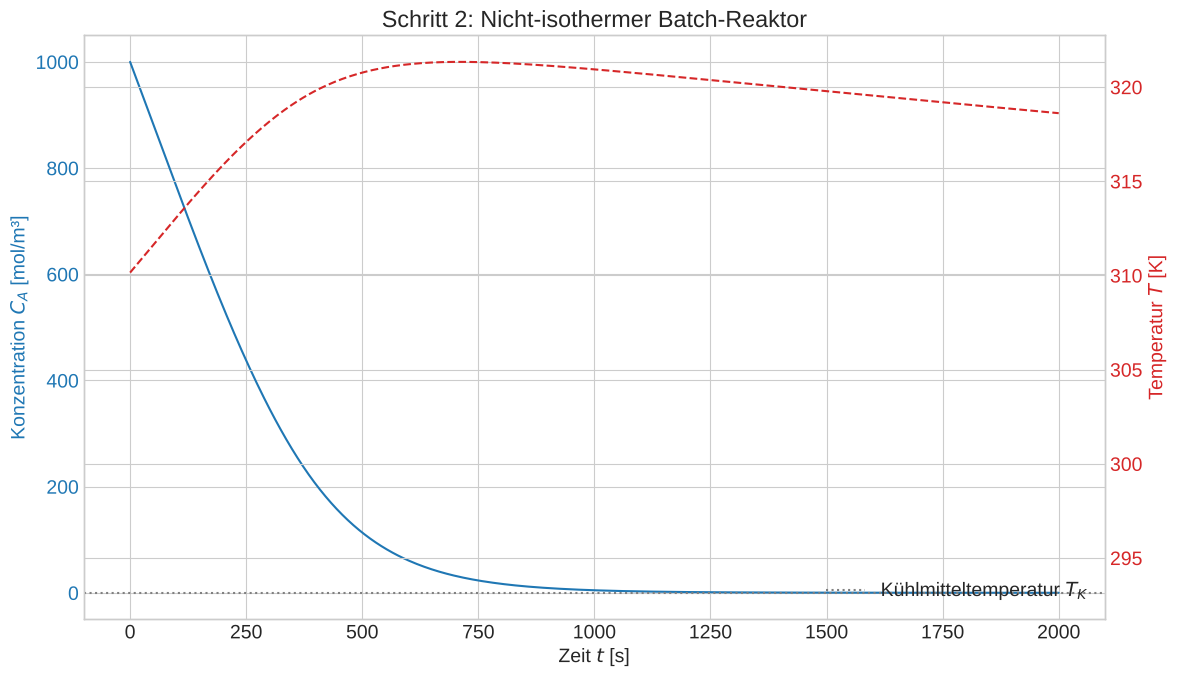

In [3]:
# --- Parameter für Schritt 2 ---
k_0 = 1e10       # Präexponentieller Faktor [1/s]
E_a = 75000      # Aktivierungsenergie [J/mol]
R = 8.314        # Universelle Gaskonstante [J/(mol*K)]
dH_R = -55000    # Reaktionsenthalpie ΔH_R [J/mol] (negativ = exotherm)
rho = 1000       # Dichte des Reaktorinhalts [kg/m^3]
c_p = 4180       # Spezifische Wärmekapazität [J/(kg*K)]
U = 150          # Wärmedurchgangskoeffizient [W/(m^2*K)]
A_W = 2.5        # Wärmeübertragungsfläche (Kühlfläche) [m^2]
V = 1.0          # Reaktorvolumen [m^3]
T_K = 293.15     # Kühlmitteltemperatur [K]

# --- Anfangsbedingungen ---
C_A0 = 1.0       # [mol/L]
T_0 = 310.15     # Starttemperatur [K] (37 °C)

# --- Zeitintervall ---
t_span = [0, 2000]  # 2000 Sekunden Simulation
t_eval = np.linspace(t_span[0], t_span[1], 500)

# --- ODE-Funktion ---
def model_step2(t, y):
    ##########, ########## = y  # C_A in [mol/m^3], T in [K]

    # 1. Arrhenius-Gleichung
    k_T = ##########

    # 2. Massenbilanz (in mol/m^3)
    dCA_dt = ##########

    # 3. Energiebilanz (wie im Skript, Abschnitt 4.2 hergeleitet)
    term_gen = ((-dH_R) / (rho * c_p)) * (k_T * C_A)
    term_cool = (U * A_W / (rho * V * c_p)) * (T - T_K)
    dT_dt = term_gen - term_cool

    return [##########, ##########]

# --- Simulation ---
y0_step2 = [C_A0 * 1000, T_0]  # Startkonzentration in mol/m^3 umrechnen
sol_step2 = solve_ivp(model_step2, t_span, y0_step2, t_eval=t_eval)

# --- Plotten ---
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot Konzentration
color = 'tab:blue'
ax1.set_xlabel('Zeit $t$ [s]')
ax1.set_ylabel('Konzentration $C_A$ [mol/m³]', color=color)
ax1.plot(sol_step2.t, sol_step2.y[0], color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Zweite Y-Achse für Temperatur
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Temperatur $T$ [K]', color=color)
ax2.plot(sol_step2.t, sol_step2.y[1], color=color, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)
ax2.axhline(T_K, color='grey', linestyle=':', label='Kühlmitteltemperatur $T_K$')
ax2.legend(loc='lower right')

plt.title('Schritt 2: Nicht-isothermer Batch-Reaktor')
fig.tight_layout()
plt.show()

### Schritt 3: DAE-System I – Stoffmengenerhaltung (Skript, Abschnitt 4.4)

Wir kehren zum isothermen Fall (Schritt 1) zurück, betrachten aber nun auch die Konzentration des Produkts $B$. Das System ist als DAE formuliert, lässt sich aber leicht durch algebraische Substitution lösen.

**Modell:**
$$
\frac{dC_A}{dt} = -k \cdot C_A
$$
$$
0 = C_A + C_B - C_{ges}
$$

**Lösung:** Wir lösen die ODE für $C_A$ und berechnen $C_B$ anschließend algebraisch: $C_B(t) = C_{ges} - C_A(t)$.

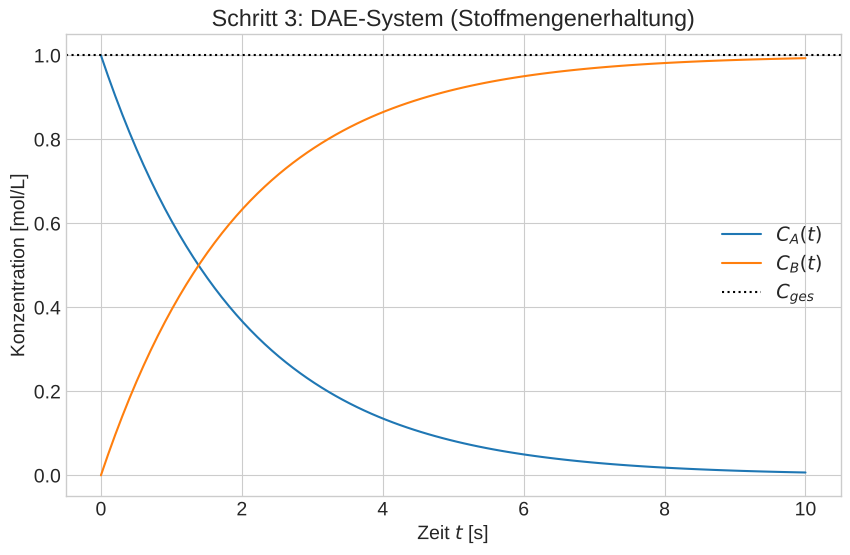

In [4]:
# --- Parameter für Schritt 3 ---
k = 0.5      # Geschwindigkeitskonstante [1/s]
C_A0 = 1.0   # [mol/L]
C_B0 = 0.0   # [mol/L]
C_ges = C_A0 + C_B0

# --- Zeitintervall ---
t_span = [0, 10]
t_eval = np.linspace(t_span[0], t_span[1], 100)

# --- ODE-Funktion (identisch zu Schritt 1) ---
# Wir lösen nur für die differentiellen Zustände
def model_step3(t, y):
    ########## = y[0]
    dCA_dt = ##########
    return [##########]

# --- Simulation ---
y0_step3 = [C_A0]
sol_step3 = solve_ivp(model_step3, t_span, y0_step3, t_eval=t_eval)

# --- Algebraische Berechnung von C_B ---
C_A_t = sol_step3.y[0]
C_B_t = ##########

# --- Plotten ---
plt.figure()
plt.plot(sol_step3.t, C_A_t, label='$C_A(t)$')
plt.plot(sol_step3.t, C_B_t, label='$C_B(t)$')
plt.axhline(C_ges, color='black', linestyle=':', label='$C_{ges}$')
plt.xlabel('Zeit $t$ [s]')
plt.ylabel('Konzentration [mol/L]')
plt.title('Schritt 3: DAE-System (Stoffmengenerhaltung)')
plt.legend()
plt.grid(True)
plt.show()

### Schritt 4: DAE-System II – Reversible Reaktion (Skript, Abschnitt 4.5)

Wir modellieren das volle kinetische System ($A \rightleftharpoons B$) mit Hin- und Rückreaktion und vergleichen das Ergebnis mit der reinen Gleichgewichtsberechnung (der algebraischen Bedingung). Das DAE-System aus dem Skript (Abschnitt 4.5) beschreibt den Grenzfall, bei dem die Kinetik so schnell ist, dass das System *immer* im Gleichgewicht ist.

**Dynamisches (kinetisches) Modell (ODEs)** mit $r = k_+(T)\, C_A - k_-(T)\, C_B$:
$$
\frac{dC_A}{dt} = -k_+(T) \cdot C_A + k_-(T) \cdot C_B
$$
$$
\frac{dC_B}{dt} = k_+(T) \cdot C_A - k_-(T) \cdot C_B
$$
$$
\frac{dT}{dt} = \frac{(-\Delta H_R)}{\rho \cdot c_p} \cdot r - \frac{U \cdot A_W}{\rho \cdot V \cdot c_p} (T - T_K)
$$

**Algebraisches (Gleichgewichts-) Modell (AEs):**
$$
K_{eq}(T) = \frac{k_+(T)}{k_-(T)} = \frac{C_B}{C_A} \quad \text{und} \quad C_A + C_B = C_{ges}
$$
Daraus folgt:
$$
C_{A,eq} = \frac{C_{ges}}{1 + K_{eq}(T)} \quad \text{und} \quad C_{B,eq} = \frac{C_{ges} \cdot K_{eq}(T)}{1 + K_{eq}(T)}
$$

**Bezeichnungen im Code:** $k_+$ → `k_plus(T)`, $k_-$ → `k_minus(T)`, $K_{eq}$ → `K_eq(T)`.

Wir simulieren das dynamische ODE-System und plotten die algebraische Gleichgewichtslösung zum Vergleich.

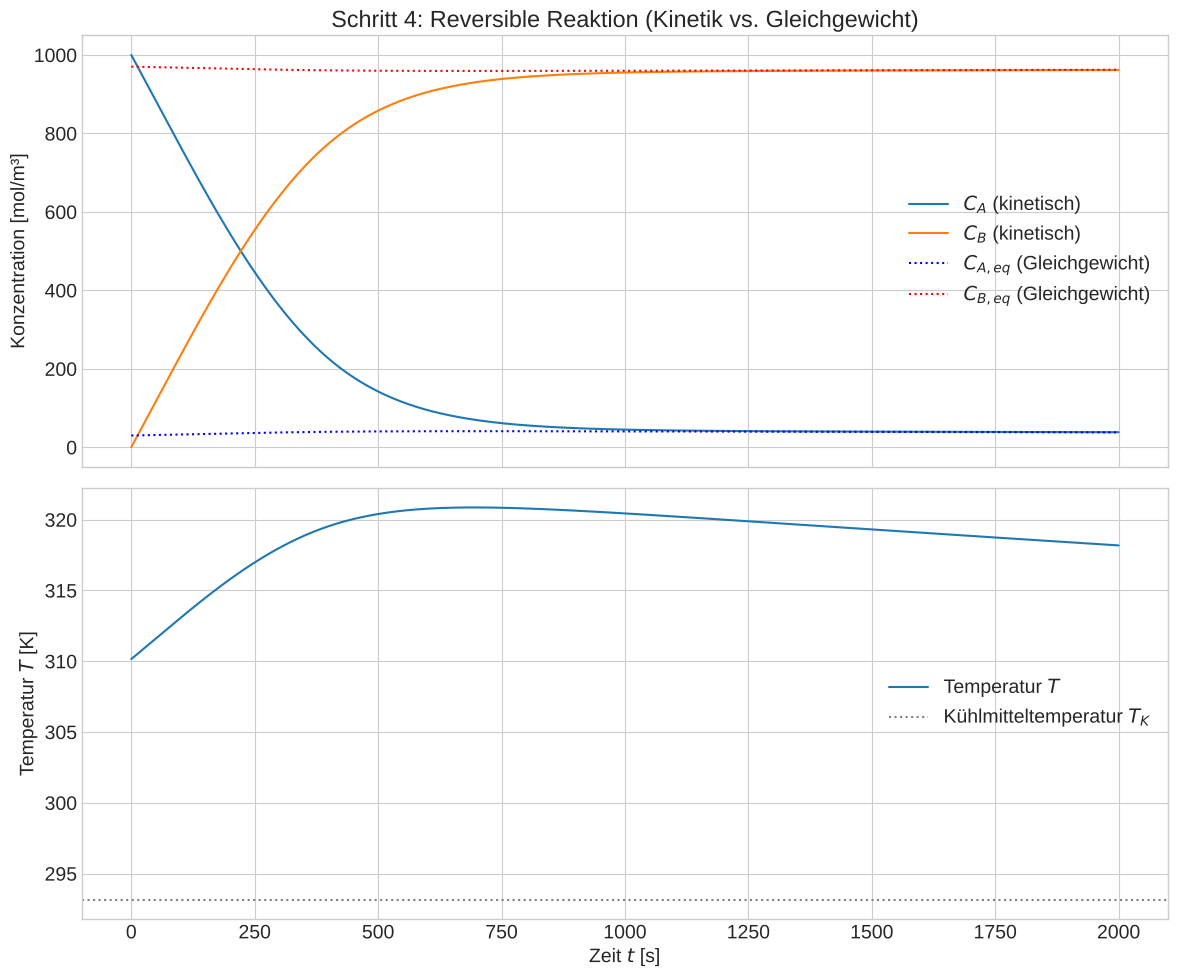

In [5]:
# --- Parameter für Schritt 4 ---
# Wir verwenden die meisten Parameter aus Schritt 2
# Neue kinetische Parameter (vereinfacht)
k_0_plus = 1e10      # Präexponentieller Faktor Hinreaktion [1/s]
E_a_plus = 75000     # Aktivierungsenergie Hinreaktion [J/mol]
k_0_minus = 5e12     # Präexponentieller Faktor Rückreaktion [1/s]
E_a_minus = 100000   # Aktivierungsenergie Rückreaktion [J/mol]

# Arrhenius-Gleichungen für Hin- und Rückreaktion
def k_plus(T):
    return ##########

def k_minus(T):
    return ##########

# Gleichgewichtskonstante K_eq(T) = k_plus / k_minus
def K_eq(T):
    k_plus_val = k_plus(T)
    k_minus_val = k_minus(T)
    # Numerische Stabilität: Verhindere Division durch Null, falls k_minus 0 ist
    return np.divide(k_plus_val, k_minus_val, out=np.full_like(k_plus_val, 1e99), where=k_minus_val != 0)

# --- ODE-System für Schritt 4 (volles kinetisches Modell) ---
def model_step4(t, y):
    C_A, C_B, T = y

    # Kinetik
    k_plus_T = k_plus(T)
    k_minus_T = k_minus(T)

    # Netto-Reaktionsgeschwindigkeit r
    r = k_plus_T * C_A - k_minus_T * C_B  # [mol/(m^3*s)]

    # 1. Massenbilanz A
    dCA_dt = ##########

    # 2. Massenbilanz B
    dCB_dt = ##########

    # 3. Energiebilanz
    term_gen = ((-dH_R) / (rho * c_p)) * r
    term_cool = (U * A_W / (rho * V * c_p)) * (T - T_K)
    dT_dt = ##########

    return [##########, ##########, ##########]

# --- Simulation ---
C_A0_4 = 1000.0  # mol/m^3
C_B0_4 = 0.0     # mol/m^3
T_0_4 = 310.15   # K

y0_step4 = [C_A0_4, C_B0_4, T_0_4]
t_span_long = [0, 2000]
t_eval_long = np.linspace(t_span_long[0], t_span_long[1], 500)

sol_step4 = solve_ivp(model_step4, t_span_long, y0_step4, t_eval=t_eval_long)

# --- Post-Processing: Gleichgewicht berechnen ---
T_verlauf = sol_step4.y[2]
K_eq_verlauf = K_eq(T_verlauf)
C_ges = C_A0_4 + C_B0_4

# C_A im Gleichgewicht
C_A_eq = C_ges / (1 + K_eq_verlauf)
# C_B im Gleichgewicht
C_B_eq = K_eq_verlauf * C_A_eq

# --- Plotten ---
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Konzentrationen
axs[0].plot(sol_step4.t, sol_step4.y[0], label='$C_A$ (kinetisch)')
axs[0].plot(sol_step4.t, sol_step4.y[1], label='$C_B$ (kinetisch)')
axs[0].plot(sol_step4.t, C_A_eq, 'b:', label='$C_{A,eq}$ (Gleichgewicht)')
axs[0].plot(sol_step4.t, C_B_eq, 'r:', label='$C_{B,eq}$ (Gleichgewicht)')
axs[0].set_ylabel('Konzentration [mol/m³]')
axs[0].legend()
axs[0].set_title('Schritt 4: Reversible Reaktion (Kinetik vs. Gleichgewicht)')

# Temperatur
axs[1].plot(sol_step4.t, sol_step4.y[2], label='Temperatur $T$')
axs[1].set_xlabel('Zeit $t$ [s]')
axs[1].set_ylabel('Temperatur $T$ [K]')
axs[1].axhline(T_K, color='grey', linestyle=':', label='Kühlmitteltemperatur $T_K$')
axs[1].legend()

plt.tight_layout()
plt.show()